In [1]:
import sys
import numpy as np
import os

import h5py

import pickle
import os
import re
import shutil
import matplotlib.pyplot as plt

# These conventions make the evaluation of bmad expressions easier
sin = np.sin; cos = np.cos; asin = np.arcsin; pi = np.pi;
in2m = 0.0254; raddeg = 57.2957795; T = True; F = False;

In [2]:
import re

class Lattice:
    def __init__(self, lattice_elems=None, lattice_params=None, lattice_beamlines=None):
        """
        Initializes a Lattice object.

        :param lattice_elems: Dictionary containing lattice elements
        :param lattice_params: Dictionary containing lattice parameters
        :param lattice_beamlines: Dictionary containing lattice beamlines
        """
        # Empty by default
        self._lattice_elems = lattice_elems if lattice_elems is not None else {}
        self._lattice_params = lattice_params if lattice_params is not None else {}
        self._lattice_beamlines = lattice_beamlines if lattice_beamlines is not None else {}

    def add_element(self, key, element):
        """
        Adds an element to the lattice_elems dictionary.

        :param key: The key for the element
        :param element: The element to add
        """
        self._lattice_elems[key] = element

    def update_params(self, key, value):
        """
        Updates or adds a parameter to the lattice_params dictionary.

        :param key: The key for the parameter
        :param value: The value of the parameter
        """
        self._lattice_params[key] = value

    def add_beamline(self, key, beamline):
        """
        Adds a beamline to the lattice_beamlines dictionary.

        :param beamline: The beamline to add
        """
        self._lattice_beamlines[key] = beamline

    def get_element(self, key):
        """
        Retrieves an element from the lattice_elems dictionary.

        :param key: The key for the element
        :return: The element if found, else None
        """
        return self._lattice_elems.get(key)

    def get_param(self, key):
        """
        Retrieves a parameter from the lattice_params dictionary.

        :param key: The key for the parameter
        :return: The parameter if found, else None
        """
        return self._lattice_params.get(key)

    def get_beamlines(self):
        """
        Retrieves the list of beamlines.

        :return: List of beamlines
        """
        return self._lattice_beamlines

    def __repr__(self):
        """
        Returns a string representation of the Lattice object.

        :return: String representation of the Lattice
        """
        return f"Lattice(elems={len(self._lattice_elems)}, params={len(self._lattice_params)}, beamlines={len(self._lattice_beamlines)})"

    def process_line(self, line):
        """
        Process a single line of the file.

        :param line: The line to process
        """
        # Match beamlines
        match_beamline_0 = re.match(r"(\w+)\s*:\s*LINE\s*=\s*(.*)", line)
        match_beamline_1 = re.match(r"(\w+):\s*line\s*=\s*(.*)", line)
        if match_beamline_0 or match_beamline_1:
            S = line.split(':')
            # Extract the key and beamline definition
            key = S[0].strip()
            beamline = S[1].split('=')[1].split(',')
            beamline = [re.sub(r'[^\w]', '', elem.strip().upper()) for elem in beamline]
            self.add_beamline(key, beamline)
            return

        # Match lattice parameters
        match_param = re.match(r"(\w+)\s*=\s*(.+)", line)
        if match_param:
            key = match_param.group(1).strip()
            value_expr = match_param.group(2).strip()
            value =  self.evaluate_expression(value_expr)
            self.update_params(key, value)
            #if key == 'ld6eb1':
                #print(f"Length of {key} was updated to {value}.");
            return

        # Match lattice elements
        match_element = re.match(r"(\w+):\s*(.*)", line)
        if match_element:
            key = match_element.group(1).strip()
            details = match_element.group(2).strip()
            details_dict = {}
            for detail in details.split(','):
                detail = detail.strip()
                if '=' in detail:
                    k, v = detail.split('=')
                    # Check if the value needs evaluation
                    if not (v.startswith('(') and v.endswith(')')) and not (v.startswith(' \"')):
                        # Might just be a float
                        try:
                            v = float(v)
                        except:
                            v = self.evaluate_expression(v.strip())
                    details_dict[k.strip()] = v
                else:
                    details_dict['class'] = detail
            self.add_element(key, details_dict)
            return

    def apply_modifications(self, line):
        """
        Check for modifications in the line and apply them to the elements.

        :param line: The line to process for modifications
        """
        match_modification = re.match(r"(\w+)\[(\w+)\]\s*=\s*(.+)", line)
        if match_modification:
            #if line.find('q1el[') >= 0:
            #    print(f"Modification at line {line}")
            element_key = match_modification.group(1).strip()
            param_key = match_modification.group(2).strip().lower()
            value_expr = match_modification.group(3).strip()
            

            
            # We need to evaluate the expression
            #evaluated_value = self.evaluate_expression(value_expr)

            # Update the element's parameter if it exists
            if element_key in self._lattice_elems:
                element = self._lattice_elems[element_key]
                # Key could be another element object
                if value_expr in self._lattice_elems:
                    element[param_key] = self._lattice_elems[value_expr]
                else:
                    # We need to evaluate the expression
                    evaluated_value = self.evaluate_expression(value_expr)
                    #if line.find('q1el[') >= 0:
                    #    print(f"{element} is being modified");
                    if evaluated_value:
                        element[param_key] = evaluated_value
                        #print(f"Updated {element_key}[{param_key}] to {evaluated_value}.")
            else:
                print(f"Element {element_key} not found.")

    def load_lattice_from_file(self, filepath):
        """
        Loads a lattice configuration from a file.

        :param filepath: Path to the lattice configuration file
        :return: A Lattice object
        """
        with open(filepath, 'r') as file:
            buffer = ""
            in_entry = False

            for line in file:
                # Remove comments, but keep whitespace
                comment_index = line.find('!')
                if comment_index != -1:
                    line = line[:comment_index]

                line = line.rstrip()  # Remove only trailing whitespace

                # Skip empty lines
                if not line:
                    if in_entry:
                        # Process accumulated buffer if entry was ongoing
                        self.process_line(buffer)
                        buffer = ""
                        in_entry = False
                    continue

                # Check if the line starts with whitespace (indicating a continuation)
                if line.startswith('        ') or line.startswith('\t'):
                    if in_entry:
                        buffer += " " + line.strip()  # Combine continuation lines
                    else:
                        # Ignore continuation lines if not in an entry
                        continue
                else:
                    # Process accumulated buffer if it exists
                    if in_entry:
                        self.process_line(buffer)
                    # Start a new entry
                    buffer = line.strip()
                    in_entry = True

                # Apply modifications on each line
                self.apply_modifications(line)

            # Process any remaining buffer after the loop
            if buffer:
                self.process_line(buffer)

        # Evaluate parameters with recursive substitution
        evaluated_params = {}
        for key, expr in self._lattice_params.items():
            # Could be a float or an expression
            try:
                evaluated_params[key] = float(expr)
            except:
                evaluated_params[key] = self.evaluate_expression(expr)

        # Update lattice_params with evaluated values
        self._lattice_params.update(evaluated_params)

    def decompose_beamline(self, beamline_name):
        """
        Decompose a beamline into a list of lattice elements.

        :param beamline_name: The name of the beamline to decompose
        :return: A list of lattice element names
        """
        if beamline_name not in self._lattice_beamlines:
            raise ValueError(f"Beamline '{beamline_name}' not found in lattice_beamlines.")

        elements = self._lattice_beamlines[beamline_name]
        resolved_elements = []

        for element in elements:
            # Special work-around for things like "WIGE_line"
            if element.find('_') >= 0:
                halfUpper = element.split('_')[0] + '_' + element.split('_')[1].lower()
            if element.lower() in self._lattice_elems:
                elem_entry = self._lattice_elems[element.lower()].copy()
                elem_entry['name'] = element.lower()
                resolved_elements.append(elem_entry)
            elif element.find('_') >= 0 and halfUpper in self._lattice_beamlines:
                sub_beamline_elements = self.decompose_beamline(halfUpper)
                resolved_elements.extend(sub_beamline_elements)
            elif element.lower() in self._lattice_beamlines or element in self._lattice_beamlines:
                try:
                    sub_beamline_elements = self.decompose_beamline(element)
                    resolved_elements.extend(sub_beamline_elements)
                except:
                    sub_beamline_elements = self.decompose_beamline(element.lower())
                    resolved_elements.extend(sub_beamline_elements)
            else:
                raise ValueError(f"Unknown element or beamline '{element}' encountered in '{beamline_name}'.")

        return resolved_elements

    def write_elements_to_file(self, elements, output_file):
        """
        Writes array of elements 'elements' to 'output_file', in the format of a pyDFCSR lattice
        Notes:
        - Diagnostics, collimators, etc. are treated as drifts of length 0.0 upon translation.
        since these elements have no equivalent in pyDFCSR as of yet. 
        - nsep is set to 1 by default
        - Step-size is set to the length of the smallest element in the entire Lattice object by default
        
        """
        # Mapping correspondence
        correspondence = {
            'sbend': 'dipole',
            'quadrupole': 'quad',
            'sextupole': 'sextupole',
            'drift': 'drift',
            'l': 'L',
            'k1': 'strength',
            'k2': 'strength',
            'class': 'type',
            'angle': 'angle',
            'E1': 'E1',
            'E2': 'E2',
            'nsep': 'nsep'
        }

        # Find minimum length scale
        minL = float('inf')
        for elem in elements:
            if 'l' in elem.keys():
                if elem['l'] > 0:
                    L = elem['l']
                    if L < minL:
                        minL = L
        print(f"Using step {minL}")

        # Open the output file for writing
        with open(output_file, 'w') as file:
            # Write header
            file.write(f"step_size: {minL}\n")
            file.write(f"#####################################\n\n")
            # Write list of elements
            for element in elements:
                element_details = element;
                if not element_details:
                    print(f"Could not find {element['name']}")
                    continue 
            
                # Write the element name
                file.write(f"{element['name']}:\n")
                # Do-Nothing Elements are length-zero drifts
                if element_details.get('class') in ['monitor', 'marker', 'hkicker', 'vkicker', 'rcollimator' ]:
                    file.write(f"  type: drift\n")
                    file.write(f"  L: 0.00\n")
                # Write attributes with the specified format
                else:
                    file.write(f"  {correspondence.get('class')}: {correspondence.get(element_details.get('class'))}\n")
                    # Write Lc(universal)
                    file.write(f"  L: {element_details.get('l')}\n")
                    
                    # Dipole parameters
                    if 'angle' in element_details:
                        file.write(f"  angle: {element_details.get('angle')}\n")
                        file.write(f"  FRINGE_AT: {'both_ends'}\n");
                        file.write(f"  FRINGE_TYPE: {'linear_edge'}\n");
                    if 'e1' in element_details:
                        file.write(f"  E1: {element_details.get('e1')}\n");
                    if 'e2' in element_details:
                        file.write(f"  E2: {element_details.get('e2')}\n");
                    if 'fint' in element_details:
                        file.write(f"  FINT: {element_details.get('fint')}\n");
                    if 'fintx' in element_details:
                        file.write(f"  FINTX: {element_details.get('fintx')}\n");
                    if 'hgap' in element_details:
                        file.write(f"  HGAP: {element_details.get('hgap')}\n");
                    if 'hgapx' in element_details:
                        file.write(f"  HGAPX: {element_details.get('hgapx')}\n");
                    if 'tilt' in element_details:
                        file.write(f"  TILT: {element_details.get('tilt')}\n");
                        
                    # Quad/Sextupole parameters
                    if element_details.get('class') in ['quadrupole']:
                        strength = element_details.get('k1')
                        file.write(f"  K1: {strength}\n")

                    if element_details.get('class') in ['sextupole']:
                        strength = element_details.get('k2')
                        file.write(f"  K2: {strength}\n")

                # Write nsep (1 by default)
                file.write(f"  nsep: {element_details.get('nsep', '1')}\n")

                # Write a newline after each element
                file.write("\n")
            print(f"Lattice written to {output_file} ")

    def evaluate_expression(self, expr):
        """
        Recursively evaluate an expression with variables replaced by their values from params.
        Handles patterns like element[key].

        :param expr: The expression as a string
        :return: Evaluated result
        """
        #if expr.find('q1el[') >= 0:
        #    print(f"Evaluating {expr}")
        def replace(match):
            # Handle pattern like element[key]
            element_key = match.group(1)
            element_field = match.group(2).lower()
            #print(f" Key {element_key}, field {element_field}")
            if element_key in self._lattice_elems:
                element = self._lattice_elems[element_key]
                return str(element.get(element_field, ''))
            return match.group(0)  # Return the original text if not found

        def evaluate_inner(expr):
            # Handle direct parameter replacement
            def param_replace(match):
                return str(self._lattice_params.get(match.group(0), match.group(0)))

            # Create a regex pattern to match all parameter names as whole words
            param_pattern = re.compile(r'\b(' + '|'.join(re.escape(key) for key in self._lattice_params.keys()) + r')\b')

            # Replace parameter names in the expression with their values
            expr = param_pattern.sub(param_replace, expr)

            # Handle patterns like element[key]
            element_pattern = re.compile(r'(\w+)\[(\w+)\]')
            expr = element_pattern.sub(replace, expr)

            return expr

        while True:
            new_expr = evaluate_inner(expr)
            if new_expr == expr:
                break
            expr = new_expr

        # Evaluate the final expression
        try: 
            return eval(expr)
        except:
            print(f"Expression {expr} could not be evaluated")
            return;

In [3]:
common_path= r'/global/homes/o/ocamacho/impact_bmad_container_notebooks/facet2-lattice/bmad/master/common.bmad'

li20_path= r'/global/homes/o/ocamacho/impact_bmad_container_notebooks/facet2-lattice/bmad/master/LI20.bmad'
# Replace 'lattice_config.txt' with your actual file path
lattice = Lattice({}, {}, {})
lattice.load_lattice_from_file(common_path)
lattice.load_lattice_from_file(li20_path)
#print(lattice)
#print("Elements:", lattice._lattice_elems)
#print("Parameters:", lattice._lattice_params)
print("Beamlines:", lattice._lattice_beamlines.keys() )
##lattice.evaluate_parameters()
#ff20h = lattice.decompose_beamline('FF20H')

Beamlines: dict_keys(['b1le_full', 'b2le_full', 'b3le_full', 'b3re_full', 'b2re_full', 'b1re_full', 'wige1_full', 'wige2_full', 'wige3_full', 'WIGE_line', 'q1el_full', 'sq1_full', 'q2el_full', 'q3el_1_full', 'q3el_2_full', 'q4el_1_full', 'q4el_2_full', 'q4el_3_full', 'q5el_full', 'q6e_full', 'q5er_full', 'q4er_1_full', 'q4er_2_full', 'q4er_3_full', 'q3er_1_full', 'q3er_2_full', 'q2er_full', 'q1er_full', 's1el_full', 's2el_full', 's3el_1_full', 's3el_2_full', 's3er_1_full', 's3er_2_full', 's2er_full', 's1er_full', 'CHICANE1', 'CHICANE2', 'BC20W', 'xtcavf_full', 'b5d36_full', 'q5ff_full', 'q4ff_full', 'q3ff_full', 'q2ff_full', 'q1ff_full', 'q0ff_full', 'q0d_full', 'q1d_full', 'q2d_full', 'FF', 'EXPT', 'SPECT', 'FF20H', 'SECTOR20'])


In [4]:
bc20_w = lattice.decompose_beamline('BC20W')

In [5]:
def consolidate_drift_elements(elements):
    # Adjacent drifts are consolidated into a single super-drift
    consolidated = []
    i = 0
    j = 0;
    while i < len(elements):
        current = elements[i]
        if current['class'] == 'drift':
            j += 1;
            total_length = current['l']
            while i + 1 < len(elements) and elements[i + 1]['class'] == 'drift':
                i += 1
                total_length += elements[i]['l']
            consolidated.append({'class': 'drift', 'l': total_length, 'name': f"D{j}" })
        else:
            consolidated.append(current)
        i += 1
    return consolidated

In [6]:
def remove_trivial(elements):
    consolidated = []
    i = 0
    while i < len(elements):
        current = elements[i]
        # Do not include length zero elements
        if current['class']  in ['monitor', 'marker', 'hkicker', 'vkicker', 'rcollimator' ]:
            #print(f"{current} is useless")
            pass;
        elif 'l' in current.keys() and current['l'] == 0:
            #print(f"{current} has length zero");
            pass;
        # Zero bend-angle wigglers are converted into drifts
        elif current['class'] == 'sbend' and  current['angle'] == 0.0 and current['e1'] == 0.0 and current['e2'] == 0:
            print(f"{current} is a useless wiggler");
            consolidated.append({'class': 'drift', 'l': current['l'], 'name': current['name']});
        else:
            #print(f"Appending {current}")
            consolidated.append(current)
        i += 1
    return consolidated

In [7]:
bc20w_c = consolidate_drift_elements( (remove_trivial(bc20_w) ) );

{'class': 'sbend', 'type': ' "SLC wiggler"', 'hgap': 0.01016, 'l': 0.244, 'angle': -0.0, 'e1': 0.0, 'fint': 0.5, 'e2': -0.0, 'fintx': 0.5, 'ref_tilt': 1.5707963267948966, 'name': 'wige1'} is a useless wiggler
{'class': 'sbend', 'type': ' "SLC wiggler"', 'hgap': 0.01016, 'l': 0.488, 'angle': 0.0, 'e1': 0.0, 'fint': 0.5, 'e2': 0.0, 'fintx': 0.5, 'ref_tilt': 1.5707963267948966, 'name': 'wige2'} is a useless wiggler
{'class': 'sbend', 'type': ' "SLC wiggler"', 'hgap': 0.01016, 'l': 0.244, 'angle': -0.0, 'e1': -0.0, 'fint': 0.5, 'e2': 0.0, 'fintx': 0.5, 'ref_tilt': 1.5707963267948966, 'name': 'wige3'} is a useless wiggler


In [8]:
step = np.array([12, 138, 272, 287, 312, 340, 435, 553]);

In [9]:
step = np.array([12, 138, 272, 287, 312, 340, 435, 553]);


spos = step * 0.0749

In [10]:
bend_pos = [];
Stot = 0.0;
for elem in bc20w_c:
    if elem['class'] == 'sbend':
        #print(elem['name']);
        bend_pos.append(Stot);
        print(Stot)
    Stot += elem['l'];
    if elem['class'] == 'sbend':
        print(Stot)
    if elem['class'] == 'sbend':   
        bend_pos.append(Stot)
bend_pos = np.array(bend_pos)


0.0
1.0630226014319473
10.413961305047525
12.238861305047525
23.61636680865081
24.14506680865081
24.938662808650808
25.467362808650808
36.84486831225409
38.66976831225409
48.020707015869675
49.08372961730162


In [11]:
bend_pos

array([ 0.        ,  1.0630226 , 10.41396131, 12.23886131, 23.61636681,
       24.14506681, 24.93866281, 25.46736281, 36.84486831, 38.66976831,
       48.02070702, 49.08372962])

In [12]:
bend_pos/0.07495

array([  0.        ,  14.18309008, 138.9454477 , 163.29367985,
       315.09495408, 322.14899011, 332.737329  , 339.79136503,
       491.59263926, 515.94087141, 640.70322903, 654.88631911])

In [64]:
dump_pos = np.array([  0.        ,  15, 
       138 , 164,
       315, 323, 
       332  , 340,
       491, 516, 
       640, 655]) * 0.074964

0.0689293050475257


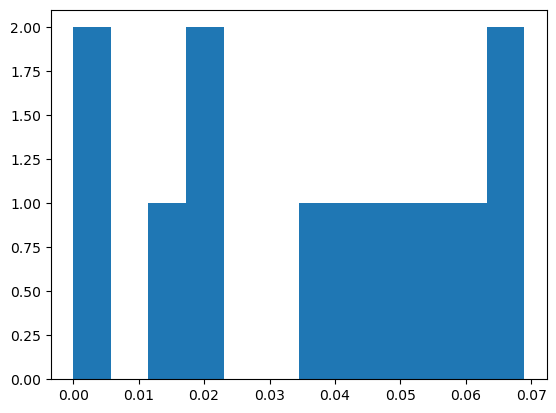

In [65]:
plt.hist(np.abs(dump_pos - bend_pos), len(dump_pos) );
print(np.max(np.abs(dump_pos - bend_pos)) )

In [14]:
np.modf(bend_pos/0.0749)[0]

array([0.        , 0.1925581 , 0.03820167, 0.40268765, 0.30529785,
       0.36404284, 0.95945005, 0.01819504, 0.92080524, 0.28529122,
       0.13093479, 0.32349289])

In [ ]:
dump_pos = np.array([  0.        ,  15, 
       138 , 164,
       315, 323, 
       332  , 340,
       491, 516, 
       640, 655]) * 0.074964

In [66]:
dump_pos

array([ 0.      ,  1.12446 , 10.345032, 12.294096, 23.61366 , 24.213372,
       24.888048, 25.48776 , 36.807324, 38.681424, 47.97696 , 49.10142 ])

In [73]:
Stot = 0.0;
for elem in bc20w_c:
    if Stot < 165*0.074964:
        Stot += elem['l']
        print(elem['name'])
    else:
        print(elem['name'])
        print(f"At position {Stot:.4f}")
        break;

b1le
D1
q1el
D2
sq1
D3
b2le
D4
q2el
At position 12.4325


In [69]:
bc20w_c

[{'class': 'sbend',
  'type': ' "0.906D40.945"',
  'hgap': 0.0115,
  'l': 1.0630226014319473,
  'angle': 0.02258935,
  'e1': 0.011294675,
  'fint': 0.5,
  'e2': 0.011294675,
  'fintx': 0.5,
  'name': 'b1le',
  'position': 0.5315113007159736,
  'color': 'deepskyblue'},
 {'class': 'drift',
  'l': 4.963388703615578,
  'name': 'D1',
  'position': 3.5447169532397362,
  'color': 'white'},
 {'class': 'quadrupole',
  'type': ' "0.813Q23"',
  'l': 0.5962,
  'aperture': 0.008325,
  'k1': 0.811267045415,
  'name': 'q1el',
  'position': 6.324511305047525,
  'color': 'red'},
 {'class': 'drift',
  'l': 2.000806,
  'name': 'D2',
  'position': 7.6230143050475245,
  'color': 'white'},
 {'class': 'quadrupole',
  'tilt': 0.7853981633974483,
  'type': ' "2.026Q14"',
  'l': 0.3813,
  'aperture': 0.025730199999999995,
  'k1': 0,
  'name': 'sq1',
  'position': 8.814067305047525,
  'color': 'red'},
 {'class': 'drift',
  'l': 1.4092440000000002,
  'name': 'D3',
  'position': 9.709339305047525,
  'color': 'whit

In [18]:
# Prepare elements for display
Stot = 0.0;
for elem in bc20w_c:
    elem['position'] = Stot + elem['l']/2;
    Stot += elem['l'];
    if elem['class'] == 'sbend':
        elem['color'] = 'deepskyblue';
    elif elem['class'] == 'quadrupole':
        elem['color'] = 'red';
    elif elem['class'] == 'sextupole':
        elem['color'] = 'greenyellow'
    else:
        elem['color'] = 'white';

-0.29909900490842484
-0.027707436362394144
0.20340609927000325
0.02152129347645937
0.20340609927000325
0.0
-0.5977414183233489
-0.02152129347645948
0.7327892653960342
0.027707436362394144


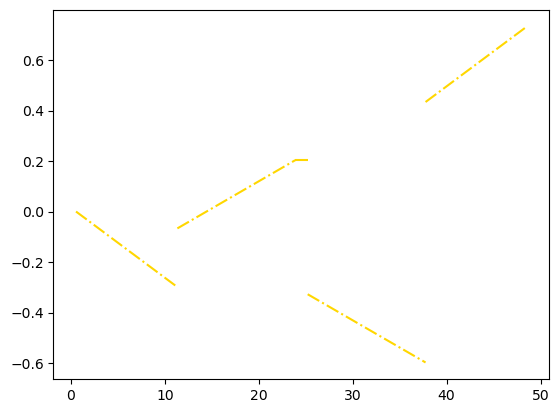

In [19]:
S = 0;
bendLocs = [];
angles = [];

for element in bc20w_c:
    S += element['l'];
    # Bend the trajectory at dipoles
    if element['class'] == 'sbend':
        bendLocs.append(S - element['l']/2); # See line 22
        angles.append(element['angle']);
sArr = np.linspace(0, S);
i = 0;
sLoc = bendLocs[0]
angle = angles[0];
yVal = 0.0;
funcs = [];
yVals = [0.0]
while( i +1 < len(bendLocs) ):
    i+=1;
    sArr = np.linspace(sLoc, bendLocs[i], 10);
    def f(s):
        angleNext = angles[i]
        m = (np.tan(angleNext) - np.tan(angle) );
        sLoc = bendLocs[0]
        y0 = yVal;
        return y0 + m*(s - sLoc)/2;
    
    plt.plot(sArr, f(sArr), c  = 'gold', linestyle = '-.')
    yVal = f(sArr[-1]); #yVal + (np.tan(angles[i]) - np.tan(angle) )*(sArr[-1] - sLoc)/2;
    print(yVal)
    #print(yVal)
    funcs.append(f);
    print( funcs[0](4) - funcs[0](3) )
    yVals.append(yVal);
    sLoc = bendLocs[i] 
    angle = angles[i]

In [20]:
funcs[0](4) - funcs[0](3)

0.0

In [21]:
for i in range(len(bendLocs)-1):
    sArr = np.linspace(bendLocs[i], bendLocs[i+1], 10);
    fi = funcs[i];
    plt.plot(sArr, fi( sArr) -  );

SyntaxError: invalid syntax (4130700082.py, line 4)

/tmp/ipykernel_2067054/2901175938.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


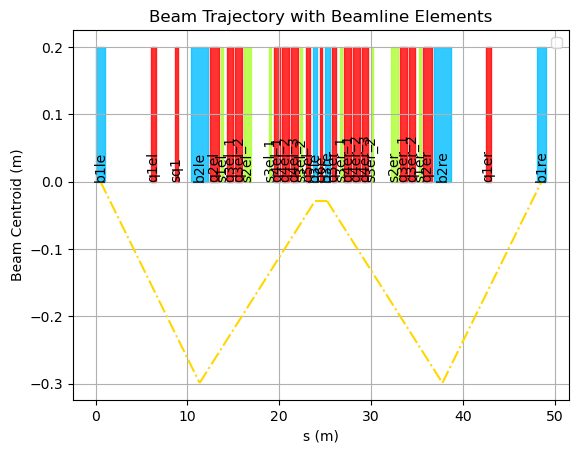

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Sample data for beam envelope
x = np.linspace(0, Stot, 500)
beam_envelope = np.sin(x)  # Example envelope

# Sample data for beamline elements with colors and lengths
beamline_elements = bc20w_c


# Plot the beamline elements as scaled colored rectangles
ax = plt.gca()
S = 0;
for element in beamline_elements:
    S += element['l'];
    if element['class'] != 'drift': # Don't plot drifts
        # Calculate rectangle position and size
        rect_x = element['position'] - element['l'] / 2  # Center the rectangle
        rect_y = 0.0  # Position below the x-axis
        rect_width = element['l']  # Use the length attribute for width
        rect_height = 0.2  # Height of the rectangle

        # Add a colored rectangle
        rect = patches.Rectangle((rect_x, rect_y), rect_width, rect_height,
                                 color=element['color'], alpha=0.8)
        ax.add_patch(rect)

        # Add a label
        plt.text(element['position'], 0.0, element['name'], rotation=90,
                 verticalalignment='bottom', horizontalalignment='center') 


# Customize the plot
plt.title('Beam Trajectory with Beamline Elements')
plt.xlabel('s (m)')
plt.ylabel('Beam Centroid (m)')
#plt.ylim([-0.6, 1.0])  # Extend the y-axis to make room for rectangles and labels
plt.legend()
plt.grid(True)

# Show centroid trajectory
i = 0;
sLoc = bendLocs[0]
angle = angles[0];
yVal = 0.0;
while( i +1 < len(bendLocs) ):
    i+=1;
    sArr = np.linspace(sLoc, bendLocs[i], 10);
    yArr = yVal + (np.tan(angles[i]) - np.tan(angle) )*(sArr - sLoc)/2;
    plt.plot(sArr, yArr, c  = 'gold', linestyle = '-.')
    yVal = yVal + (np.tan(angles[i]) - np.tan(angle) )*(sArr[-1] - sLoc)/2;
    
    sLoc = bendLocs[i] 
    angle = angles[i]
    
    
# Show the plot
plt.show()


In [81]:
d_step = 0.074964;
dump_pos/d_step

array([  0.,  15., 138., 164., 315., 323., 332., 340., 491., 516., 640.,
       655.])

In [78]:
dump_pos

array([ 0.      ,  1.12446 , 10.345032, 12.294096, 23.61366 , 24.213372,
       24.888048, 25.48776 , 36.807324, 38.681424, 47.97696 , 49.10142 ])

In [142]:
np.tan(np.array(angles)) - np.array(angles)

array([ 3.84307272e-06, -1.17782446e-05,  3.55893350e-07,  3.55893350e-07,
       -1.17782446e-05,  3.84307272e-06])

In [14]:
#postbc20w = consolidate_drift_elements( (remove_trivial(postbc20w) ) )

In [ ]:
#out_path = r'/global/homes/o/ocamacho/pydfCSR_sims/lattice_files/postbc20w.yaml';
#lattice.write_elements_to_file(postbc20w,  out_path)

In [ ]:
#out_path = r'/global/homes/o/ocamacho/pydfCSR_sims/lattice_files/bc20w_c.yaml';
#lattice.write_elements_to_file(bc20w_c,  out_path)

In [ ]:
#bc20w = remove_trivial(bc20w)

In [ ]:
#out_path = r'/global/homes/o/ocamacho/pydfCSR_sims/lattice_files/bc20w.yaml';
#lattice.write_elements_to_file(bc20w,  out_path)